In [7]:
"""
AI-Generated Email Evaluation System
Implements 6 evaluation metrics based on research framework
WITH FEW-SHOT PROMPTING
"""

# ============================================================================
# INSTALLATION & SETUP
# ============================================================================

# Install required packages
# !pip install openai anthropic google-generativeai sentence-transformers scikit-learn pandas numpy tenacity -q

import os
import json
import time
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
import openai
from tenacity import retry, stop_after_attempt, wait_random_exponential

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration for API keys and model selection"""

    # ============================================================================
    # OPENROUTER CONFIGURATION
    # ============================================================================
    # Set your OpenRouter API key here
    OPENROUTER_API_KEY = "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"

    # OpenRouter base URL
    OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

    # Choose your model from OpenRouter's catalog
    # Examples:
    # - "openai/gpt-4o"
    # - "anthropic/claude-sonnet-4"
    # - "google/gemini-2.5-flash"
    # - "anthropic/claude-3.5-haiku"
    # - "openai/gpt-4o-mini"
    # - "google/gemma-3-4b-it"
    EVALUATION_MODEL = "x-ai/grok-4-fast"


    # Semantic entropy settings
    N_SEMANTIC_SAMPLES = 5  # Number of outputs to generate for semantic entropy

    # API Pricing (USD per 1M tokens) - OpenRouter pricing
    PRICING = {
    # OpenAI Models
    'openai/gpt-5': {'input': 1.25, 'output': 10.0},
    'openai/gpt-5-chat': {'input': 1.25, 'output': 10.0},
    'openai/gpt-4o': {'input': 2.5, 'output': 10.0},
    'openai/gpt-4-turbo': {'input': 10.0, 'output': 30.0},
    'openai/gpt-4o-mini': {'input': 0.15, 'output': 0.6},

    # Anthropic Models
    'anthropic/claude-sonnet-4': {'input': 3.0, 'output': 15.0},
    'anthropic/claude-3.5-haiku': {'input': 0.8, 'output': 4.0},
    'anthropic/claude-3-haiku': {'input': 0.25, 'output': 1.25},

    # Google Models
    'google/gemini-2.5-flash': {'input': 0.3, 'output': 2.5},
    'google/gemini-2.5-pro': {'input': 1.25, 'output': 10.0},
    'google/gemma-3-4b-it': {'input': 0.017, 'output': 0.068},

    # Qwen Models
    'qwen/qwen-2.5-72b-instruct': {'input': 0.35, 'output': 0.4},
    'qwen/qwen2.5-vl-72b-instruct': {'input': 0.0, 'output': 0.0},
    'qwen/qwen3-coder-30b-a3b-instruct': {'input': 0.06, 'output': 0.25},

    # Meta Models
    'meta-llama/llama-3.3-70b-instruct': {'input': 0.35, 'output': 0.4},

    # Mistral Models
    'mistralai/mistral-small-3.2-24b-instruct:free': {'input': 0.0, 'output': 0.0},

    # xAI Models
    'x-ai/grok-4-fast': {'input': 0.20, 'output': 0.50},

    # Amazon Models
    'amazon/nova-micro-1.0': {'input': 0.035, 'output': 0.14},

    # DeepSeek Models
    'deepseek/deepseek-v3-0324': {'input': 0.24, 'output': 0.84},
    'deepseek/deepseek-v3': {'input': 0.3, 'output': 0.85},

    # Llama Models:
    'sao10k/l3-lunaris-8b': {'input': 0.04, 'output': 0.05},
    }

    @classmethod
    def setup(cls):
        """Setup OpenRouter client"""
        # Configure OpenAI client to use OpenRouter
        client = openai.OpenAI(
            api_key=cls.OPENROUTER_API_KEY,
            base_url=cls.OPENROUTER_BASE_URL,
            default_headers={
                "HTTP-Referer": "https://github.com/yourusername/email-eval",  # Optional
                "X-Title": "Email Evaluation System",  # Optional
            }
        )
        return {
            'openai': client,  # This client works for all OpenRouter models
            'openrouter': client
        }

    @classmethod
    def get_model_cost(cls, model: str, input_tokens: int, output_tokens: int) -> float:
        """Calculate cost for a model call"""
        if model not in cls.PRICING:
            # If model not in pricing dict, return 0 (unknown cost)
            print(f"⚠️  Warning: No pricing info for model '{model}'. Cost tracking disabled.")
            return 0.0

        pricing = cls.PRICING[model]
        input_cost = (input_tokens / 1_000_000) * pricing['input']
        output_cost = (output_tokens / 1_000_000) * pricing['output']
        return input_cost + output_cost

# ============================================================================
# DATA STRUCTURES
# ============================================================================

@dataclass
class EvaluationResult:
    """Store evaluation results for a single email"""
    hallucination_score: int  # Binary: 0 or 1
    # semantic_entropy: float
    cta_quality: int  # 1-5
    language_quality: int  # 1-5
    personalization: int  # 1-5
    human_likeness: int  # 1-5
    instruction_adherence: int  # 1-5

    overall_score: float
    is_acceptable: bool
    detailed_feedback: Dict

    # Cost tracking
    total_cost: float
    input_tokens: int
    output_tokens: int
    api_calls: int

    def to_dict(self):
        return {
            'hallucination_score': self.hallucination_score,
            # 'semantic_entropy': self.semantic_entropy,
            'cta_quality': self.cta_quality,
            'language_quality': self.language_quality,
            'personalization': self.personalization,
            'human_likeness': self.human_likeness,
            'instruction_adherence': self.instruction_adherence,
            'overall_score': self.overall_score,
            'is_acceptable': self.is_acceptable,
            'total_cost_usd': self.total_cost,
            'input_tokens': self.input_tokens,
            'output_tokens': self.output_tokens,
            'api_calls': self.api_calls,
            'detailed_feedback': self.detailed_feedback
        }

# ============================================================================
# LLM-AS-JUDGE EVALUATOR
# ============================================================================

class LLMEvaluator:
    """
    Uses LLM-as-judge approach for evaluating email quality
    Works with OpenRouter API
    """

    def __init__(self, model: str = Config.EVALUATION_MODEL):
        self.model = model
        self.clients = Config.setup()
        self.client = self.clients['openrouter']  # Use OpenRouter client for all models
        self.total_input_tokens = 0
        self.total_output_tokens = 0
        self.total_api_calls = 0
        self.total_cost = 0.0

    @retry(wait=wait_random_exponential(multiplier=1, max=60), stop=stop_after_attempt(3))
    def _call_llm(self, prompt: str) -> Tuple[str, int, int]:
        """
        Call LLM via OpenRouter with retry mechanism
        Returns: (response, input_tokens, output_tokens)
        """
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                response_format={ "type": "json_object" } # Request JSON object
            )

            input_tokens = response.usage.prompt_tokens
            output_tokens = response.usage.completion_tokens
            content = response.choices[0].message.content

            # Track usage
            self.total_input_tokens += input_tokens
            self.total_output_tokens += output_tokens
            self.total_api_calls += 1

            # Calculate cost
            cost = Config.get_model_cost(self.model, input_tokens, output_tokens)
            self.total_cost += cost

            return content, input_tokens, output_tokens

        except openai.APIError as e:
            print(f"❌ API Error calling OpenRouter API: {e}")
            # Re-raise the exception to trigger retry
            raise
        except Exception as e:
            print(f"❌ Error calling OpenRouter API: {e}")
            raise

    def reset_usage(self):
        """Reset usage counters"""
        self.total_input_tokens = 0
        self.total_output_tokens = 0
        self.total_api_calls = 0
        self.total_cost = 0.0

    def get_usage_stats(self) -> Dict:
        """Get current usage statistics"""
        return {
            'total_input_tokens': self.total_input_tokens,
            'total_output_tokens': self.total_output_tokens,
            'total_api_calls': self.total_api_calls,
            'total_cost_usd': round(self.total_cost, 4)
        }

    @staticmethod
    def safe_json_loads(text: str):
        """Robustly parse possibly wrapped JSON from model output."""
        import json, re

        if not text or not text.strip():
            raise ValueError("Empty LLM response")

        s = text.strip()

        # 去掉 ```json ... ``` 包裹
        if s.startswith("```"):
            s = s.strip("` \n")
            if s.lower().startswith("json"):
                s = s[4:].strip()

        # 尝试直接解析
        try:
            return json.loads(s)
        except json.JSONDecodeError:
            pass

        # 提取第一个 { 到最后一个 } 再试
        start, end = s.find("{"), s.rfind("}")
        if 0 <= start < end:
            snippet = s[start:end+1]
            try:
                return json.loads(snippet)
            except json.JSONDecodeError:
                pass

        # 替换单引号为双引号重试
        s2 = re.sub(r"(?<!\\)'", '"', s)
        return json.loads(s2)

    def evaluate_hallucination(self, email: str, user_prompt: str) -> Tuple[int, str]:
        """Evaluate Hallucination (Binary Score: 0 or 1)"""
        prompt = f"""Evaluate the hallucination of this email on a binary scale of 0 or 1.

Description: A binary check for whether the model either fabricated information.

Scoring:
0: No Critical Failure. The output contains no fabricated information.
1: Critical Failure Present. The output contains a clear and misleading falsehood that breaks trust or has made up information not in the JSON.

EXAMPLE 1:
Email: "Hi Lubaina, Saw recent interest in content around targeted advertising and account-based strategies. It seems you may be digging into ways to drive stronger campaign performance. It's hard to act on anonymous site visits when you can't tailor the message or re-engage them later. Demandbase shows which companies visit your site and adapts the experience in real time. That means deeper engagement and less wasted spend. Open to a 15-min chat to see if this is worth your time?"
User Prompt Context: Contains recipient data showing "High Value Page Visits" with URL "demandbase.com/why-demandbase/6sense" and intent keywords including "targeted advertising" and "account based"
Score: 0
Reasoning: Email accurately references recipient's documented interest in targeted advertising and account-based strategies from the provided data. No fabricated information present.

EXAMPLE 2:
Email: "Hey Taylor, Thought you may be interested in how you could significantly increase organic search traffic. Wyndly used Parse.ly to grow theirs by 5,300%. They focused on analyzing what content ranked well, identified new keyword opportunities, and optimized existing pages to match audience intent."
User Prompt Context: Instructions mention using case study from "https://www.parse.ly/resource/wyndly-increase-organic-search-traffic/"
Score: 0
Reasoning: The 5,300% statistic and strategies described align with the referenced case study source. Information is verifiable and not fabricated.

EXAMPLE 3:
Email: "Hey Steve, Saw the Argus launch — a big move for a CTO shaping secure deployments. I mostly work with tech leaders like you, helping tackle security and compliance through simplified cloud management."
User Prompt Context: Contains company news about "Network Innovations Launches Argus" platform
Score: 0
Reasoning: Email references real company news (Argus launch) provided in the data. No hallucinated facts about the recipient or company.

Now evaluate this email:

Email:
{email}

{f"User Prompt Context: {user_prompt[:500]}..." if user_prompt and len(user_prompt) > 500 else f"User Prompt Context: {user_prompt}" if user_prompt else ""}

Respond *only* with a JSON object containing 'score' (0 or 1) and 'reasoning' (string):
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
            result = self.safe_json_loads(response_text)
            return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."

    def evaluate_cta_quality(self, email: str) -> Tuple[int, str]:
        """Evaluate Call-to-Action quality (1-5 scale)"""
        prompt = f"""Evaluate the Call-to-Action (CTA) quality of this email on a scale of 1-5.

Evaluation Criteria:
- Clarity: Is the desired action clear?
- Relevance: Does it align with the email's purpose?
- Effectiveness: Is it compelling and low-friction?
- Appropriateness: Does it fit the context?

Scoring:
5: Excellent. The CTA is compelling, low-friction, contextually perfect, and directly supports the email's goal.
4: Good. The CTA is clear and relevant but could be more compelling or better phrased.
3: Average. The CTA is functional but generic or weak (e.g., "Let me know your thoughts").
2: Poor. The CTA is vague, confusing, or mismatched with the email's tone/goal.
1: Very Poor. The CTA is missing, inappropriate, or makes no sense.

EXAMPLE 1:
Email ends with: "Open to a 15-min chat to see if this is worth your time?"
Score: 5
Reasoning: CTA is specific (15-min chat), low-friction (soft ask with "open to"), and shows respect for recipient's time ("see if this is worth your time"). Clear next step without pressure.

EXAMPLE 2:
Email ends with: "Would you be open to a quick call to see how we could do the same for you?"
Score: 4
Reasoning: Clear CTA with specific action (quick call), relevant to value proposition discussed. Could be slightly more specific about duration or timing, but overall strong and appropriate.

EXAMPLE 3:
Email ends with: "Worth a quick chat to see if similar automation could strengthen your approach?"
Score: 5
Reasoning: Low-friction ("worth a quick chat"), ties directly to pain points discussed (automation, strengthening approach), and uses consultative framing rather than sales pressure.

Now evaluate this email:

Email:
{email}

Respond *only* with a JSON object containing 'score' (integer 1-5) and 'reasoning' (string):
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
          result = self.safe_json_loads(response_text)
          return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."

    def evaluate_language_quality(self, email: str) -> Tuple[int, str]:
        """Evaluate language quality and coherence (1-5 scale)"""
        prompt = f"""Evaluate the language quality and structural coherence of this email on a scale of 1-5.

Evaluation Criteria:
- Grammar and spelling
- Vocabulary appropriateness
- Sentence structure variety
- Conciseness (no unnecessary repetition)
- Punctuation and formatting

Scoring:
5: Excellent - Free of errors with appropriate vocabulary, concise presentation, varied sentences, and proper formatting.
4: Good - Mostly error-free with minor issues in vocabulary, conciseness, sentence variety, or formatting.
3: Average - Some major errors present with noticeable issues in vocabulary, repetition, sentence variety, or formatting.
2: Poor - Numerous errors with inappropriate vocabulary, significant repetition, limited sentence variety, and formatting issues.
1: Very Poor - Pervasive errors that impede comprehension with inappropriate vocabulary, excessive repetition, and poor formatting.

EXAMPLE 1:
Email: "Hi Lubaina, Saw recent interest in content around targeted advertising and account-based strategies. It seems you may be digging into ways to drive stronger campaign performance. It's hard to act on anonymous site visits when you can't tailor the message or re-engage them later. Demandbase shows which companies visit your site and adapts the experience in real time. That means deeper engagement and less wasted spend. Open to a 15-min chat to see if this is worth your time?"
Score: 5
Reasoning: No grammatical errors, clear and professional vocabulary, varied sentence structures (short opener, compound sentences, simple conclusion). Concise with no repetition. Well-formatted with proper paragraph breaks.

EXAMPLE 2:
Email: "Hey Taylor, Thought you may be interested in how you could significantly increase organic search traffic. Wyndly used Parse.ly to grow theirs by 5,300%. They focused on analyzing what content ranked well, identified new keyword opportunities, and optimized existing pages to match audience intent. They also monitored engagement to guide real-time updates, which kept their content relevant and discoverable. Would you be open to a quick call to see how we could do the same for you?"
Score: 4
Reasoning: Generally strong language quality with clear vocabulary and good sentence variety. Minor awkwardness in "grow theirs" (should be "grow their traffic" or "grow it"). Overall concise and well-structured with effective use of specifics (5,300% metric).

EXAMPLE 3:
Email: "Hey Steve, Saw the Argus launch — a big move for a CTO shaping secure deployments. I mostly work with tech leaders like you, helping tackle security and compliance through simplified cloud management. When these challenges pile up, teams lose speed and security gaps widen, making innovation harder to sustain. Worth a quick chat to see if similar automation could strengthen your approach?"
Score: 5
Reasoning: Excellent grammar and punctuation (proper em dash usage), professional vocabulary appropriate for CTO audience, varied sentence structures (fragment opener, simple, compound, and complex sentences). Concise without repetition, effective parallel structure ("lose speed...gaps widen").

Now evaluate this email:

Email:
{email}

Respond *only* with a JSON object containing 'score' (integer 1-5) and 'reasoning' (string):
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
            result = self.safe_json_loads(response_text)
            return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."


    def evaluate_personalization(self, email: str, recipient_data: Dict) -> Tuple[int, str]:
        """Evaluate personalization and personalization (1-5 scale)"""
        prompt = f"""Evaluate how well this email is tailored to the specific recipient and addresses their relevant needs.

Evaluation Criteria (50% each):

1. Recipient-Specific Tailoring
   - Uses at least 2 relevant data points (role, company, activities, signals).
   - Integrates details coherently (not a list or forced insertion).
   - Avoids prohibited info: founding year, employee count, work history >4 years.

2. Relevance & Value
   - Addresses a real challenge or opportunity specific to the recipient's role.
   - Provides tangible value or actionable next step for the recipient.
   - Tone and timing fit their current context.

Scoring guidelines:
- 5: Highly personalized; clear unique value; deep understanding of recipient.
- 4: Good personalization; relevant and useful.
- 3: Basic personalization; somewhat generic but relevant.
- 2: Minimal personalization; loosely relevant.
- 1: Generic; no relevance or value.

EXAMPLE 1:
Email: "Hi Lubaina, Saw recent interest in content around targeted advertising and account-based strategies. It seems you may be digging into ways to drive stronger campaign performance. It's hard to act on anonymous site visits when you can't tailor the message or re-engage them later. Demandbase shows which companies visit your site and adapts the experience in real time. That means deeper engagement and less wasted spend. Open to a 15-min chat to see if this is worth your time?"
Recipient Data: Digital Marketing Manager at NRG Energy, recent high-value page visits about "targeted advertising" and "account based" strategies, intent keywords include "predictive analytics" and "ad tech"
Score: 5
Reasoning: Excellent personalization using 3+ data points (intent keywords, page visit behavior, role). Naturally weaves in "targeted advertising and account-based strategies" without listing. Addresses specific challenge relevant to Digital Marketing Manager (anonymous site visits, retargeting). Value proposition directly solves stated pain point with measurable outcomes (deeper engagement, less wasted spend).

EXAMPLE 2:
Email: "Hey Taylor, Thought you may be interested in how you could significantly increase organic search traffic. Wyndly used Parse.ly to grow theirs by 5,300%. They focused on analyzing what content ranked well, identified new keyword opportunities, and optimized existing pages to match audience intent."
Recipient Data: Marketing Manager at Scholastic (publishing company), work history includes marketing roles at HarperCollins and Houghton Mifflin Harcourt
Score: 4
Reasoning: Good personalization for Marketing Manager role - organic search traffic is relevant pain point for content-heavy publishing industry. Uses concrete case study (5,300% growth) with specific tactics relevant to recipient's domain. Could be stronger by referencing recipient's publishing background or Scholastic's content needs. Still provides clear value with actionable strategies.

EXAMPLE 3:
Email: "Hey Steve, Saw the Argus launch — a big move for a CTO shaping secure deployments. I mostly work with tech leaders like you, helping tackle security and compliance through simplified cloud management. When these challenges pile up, teams lose speed and security gaps widen, making innovation harder to sustain. Worth a quick chat to see if similar automation could strengthen your approach?"
Recipient Data: CTO at Network Innovations (telecommunications, 351 employees), recent company news about launching "Argus" software-defined security platform
Score: 5
Reasoning: Highly personalized using recent company news (Argus launch) and role (CTO). Naturally connects launch to recipient's responsibilities (secure deployments). Addresses CTO-level concerns (security, compliance, team velocity, innovation sustainability). Pain point highly relevant to role managing platform launch. Value prop ("similar automation") ties directly to recipient's current context.

Now evaluate this email:

Email:
{email}

Recipient Data:
{json.dumps(recipient_data, indent=2) if recipient_data else "No recipient data provided"}

Respond *only* with a JSON object containing 'score' (integer 1-5) and 'reasoning' (string):
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
            result = self.safe_json_loads(response_text)
            return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."


    def evaluate_human_likeness(self, email: str) -> Tuple[int, str]:
        """Evaluate how human-like the email sounds (1-5 scale)"""
        prompt = f"""Evaluate whether this email reads like it was written by a real person with natural thought patterns and authentic voice.

Evaluation Criteria:

- Naturalness: Conversational tone? Appropriate informality? Authentic voice?
- Lexical Diversity: Balanced vocabulary richness? Natural word variety without forced sophistication?
- Conciseness: Direct and efficient? Avoids unnecessary verbosity or over-explanation?
- Emotional Authenticity: Genuine emotional expression? Appropriate sentiment depth and variety?
- Structural Naturalness: Varied sentence structure? Natural flow without excessive complexity or formulaic patterns?

Scoring:

5: Highly Human-like - Conversational and authentic tone; balanced vocabulary with natural uniqueness; concise and direct; genuine emotional depth with varied sentiment; natural sentence variety and flow
4: Mostly Human-like - Generally natural tone; good vocabulary balance; reasonably concise; authentic emotions present; varied structure with minor formulaic elements
3: Ambiguous - Somewhat formal or generic tone; unbalanced vocabulary (too repetitive or artificially diverse); moderately verbose; limited emotional range; some overly complex or uniform sentences
2: Likely AI-generated - Overly formal or polished tone; excessive use of sophisticated vocabulary or high repeatability; verbose with unnecessary elaboration; shallow or mismatched emotional expressions; complex sentence structures or excessive uniformity
1: Clearly AI-generated - Robotic or excessively formal tone; unnatural vocabulary patterns (overuse of rare words or excessive repetition); extremely verbose with redundant content; generic or contextually inappropriate emotions; highly formulaic or unnaturally complex structures; lacks personal voice entirely

EXAMPLE 1:
Email: "Hi Lubaina, Saw recent interest in content around targeted advertising and account-based strategies. It seems you may be digging into ways to drive stronger campaign performance. It's hard to act on anonymous site visits when you can't tailor the message or re-engage them later. Demandbase shows which companies visit your site and adapts the experience in real time. That means deeper engagement and less wasted spend. Open to a 15-min chat to see if this is worth your time?"
Score: 5
Reasoning: Highly conversational with natural opener ("Saw recent interest"). Vocabulary is professional but accessible, no forced sophistication. Concise sentences that flow naturally. Appropriate emotional neutrality for cold outreach with subtle empathy ("it's hard"). Sentence variety with fragments, simple, and compound structures. Reads like authentic human sales communication.

EXAMPLE 2:
Email: "Hey Taylor, Thought you may be interested in how you could significantly increase organic search traffic. Wyndly used Parse.ly to grow theirs by 5,300%. They focused on analyzing what content ranked well, identified new keyword opportunities, and optimized existing pages to match audience intent. They also monitored engagement to guide real-time updates, which kept their content relevant and discoverable. Would you be open to a quick call to see how we could do the same for you?"
Score: 4
Reasoning: Natural conversational tone with casual opener. Good vocabulary balance - specific technical terms where needed but not overdone. Mostly concise though slightly verbose in explaining tactics. Genuine enthusiasm comes through without being pushy. Sentence variety is good but slight formulaic quality in the tactical explanation section. Overall reads as human-written with minor polish.

EXAMPLE 3:
Email: "Hey Steve, Saw the Argus launch — a big move for a CTO shaping secure deployments. I mostly work with tech leaders like you, helping tackle security and compliance through simplified cloud management. When these challenges pile up, teams lose speed and security gaps widen, making innovation harder to sustain. Worth a quick chat to see if similar automation could strengthen your approach?"
Score: 5
Reasoning: Authentic peer-to-peer tone ("big move," "tech leaders like you"). Balanced vocabulary - technical where appropriate but conversational overall. Very concise with no wasted words. Natural emotional authenticity through understated concern about challenges. Excellent sentence variety (fragment opener, em dash, compound sentences). Flows like natural human thought process.

Now evaluate this email:

Email:
{email}

Respond *only* with a JSON object containing 'score' (integer 1-5) and 'reasoning' (string):
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
            result = self.safe_json_loads(response_text)
            return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."

    def evaluate_instruction_adherence(self, email: str, instructions: str, user_prompt: str) -> Tuple[int, str]:
        """Evaluate adherence to given instructions (1-5 scale)"""
        prompt = f"""Evaluate how well this email adheres to the given instructions.

Evaluation Criteria:
- Completeness: Includes all required components
- Accuracy: Follows instructions without deviation
- Tone & Style: Maintains required tone
- Alignment with Goals: Achieves intended purpose
- Avoidance of Unnecessary Content: No irrelevant information

Scoring:
5: Excellent - Fully adheres with no deviations
4: Good - Mostly adheres with minor omissions
3: Average - Partially adheres, several deviations
2: Poor - Frequently fails to follow key instructions
1: Very Poor - Does not follow instructions at all

EXAMPLE 1:
Email: "Hi Lubaina, Saw recent interest in content around targeted advertising and account-based strategies. It seems you may be digging into ways to drive stronger campaign performance. It's hard to act on anonymous site visits when you can't tailor the message or re-engage them later. Demandbase shows which companies visit your site and adapts the experience in real time. That means deeper engagement and less wasted spend. Open to a 15-min chat to see if this is worth your time?"
Instructions: Under 100 words, skip line after paragraphs, use "Hi" or "Hey" with first name, grade 5 reading level, conversational tone, avoid exclamation marks, end with clear simple CTA, avoid email clichés, only one question at end
Score: 5
Reasoning: Perfect adherence. 70 words (under 100), proper line breaks, "Hi Lubaina" salutation, conversational grade-5 language, no exclamations, clear low-friction CTA at end, single question placement, no clichés used, appropriate tone throughout.

EXAMPLE 2:
Email: "Hey Taylor, Thought you may be interested in how you could significantly increase organic search traffic. Wyndly used Parse.ly to grow theirs by 5,300%. They focused on analyzing what content ranked well, identified new keyword opportunities, and optimized existing pages to match audience intent. They also monitored engagement to guide real-time updates, which kept their content relevant and discoverable. Would you be open to a quick call to see how we could do the same for you? Best Regards, Julian WordPress VIP"
Instructions: Under 90 words, "Hey" preferred, first paragraph under 20 words, short sentences (<10 words), proper signature with cycling closings, grade 5 reading level, avoid clichés
Score: 4
Reasoning: Good adherence with minor issues. 87 words (under 90), "Hey Taylor" correct, proper signature format with "Best Regards," clear CTA. However, some sentences exceed 10 words ("They focused on analyzing what content ranked well" is 9 words but others are longer). First paragraph is 13 words (good). No clichés. Overall strong compliance with minor sentence length deviations.

EXAMPLE 3:
Email: "Hey Steve, Saw the Argus launch — a big move for a CTO shaping secure deployments. I mostly work with tech leaders like you, helping tackle security and compliance through simplified cloud management. When these challenges pile up, teams lose speed and security gaps widen, making innovation harder to sustain. Worth a quick chat to see if similar automation could strengthen your approach? Thanks, Noah"
Instructions: Under 90 words, short sentences (<10 words), skip line after sentences, I:You ratio <1, one question at end, proper signature, grade 10 reading level, peer tone, avoid clichés
Score: 5
Reasoning: Excellent adherence. 66 words (under 90), mostly short sentences with good rhythm, proper line breaks, I:You ratio favorable (more "you/your" than "I"), single question at end, proper signature with "Thanks, Noah," appropriate grade 10 vocabulary, peer-to-peer tone achieved, no clichés, curious not complimentary as instructed.

Now evaluate this email:

Email:
{email}

Instructions:
{instructions if instructions else "No specific instructions provided"}

User Prompt:
{user_prompt if user_prompt else "No user prompt provided"}

Respond *only* with a JSON object containing 'score' (integer 1-5) and 'reasoning': '<one line, no line breaks>':
"""

        response_text, _, _ = self._call_llm(prompt)
        try:
            result = self.safe_json_loads(response_text)
            return result.get('score', -1), result.get('reasoning', 'No reasoning found')
        except Exception as e:
            print(f"❌ JSON Decode Error: {e}")
            print(f"Raw LLM response: {response_text}")
            return -1, f"Error parsing LLM response: {response_text[:200]}..."


# ============================================================================
# MAIN EVALUATION PIPELINE
# ============================================================================

class EmailEvaluationPipeline:
    """
    Complete evaluation pipeline for AI-generated emails
    Works with OpenRouter API
    """

    def __init__(self, model: str = Config.EVALUATION_MODEL):
        self.llm_eval = LLMEvaluator(model)
        self.clients = Config.setup()
        self.openrouter_client = self.clients['openrouter']

    def evaluate_email(
        self,
        email: str,
        instructions: str = "",
        user_prompt: str = "",
        recipient_data: Dict = None,
        context: str = "",
        check_hallucination: bool = True
    ) -> EvaluationResult:
        """
        Comprehensive email evaluation

        Args:
            email: The email text to evaluate
            instructions: Original instructions for email generation
            user_prompt: User instructions for email generation
            recipient_data: Dict with recipient information (role, company, etc.)
            context: Additional context for relevance evaluation
            check_hallucination: Whether to run semantic entropy check (slower)
        """

        start_time = time.time()
        print("Starting evaluation...")
        detailed_feedback = {}

        # Reset usage counters for this evaluation
        self.llm_eval.reset_usage()

        # 1. Hallucination Detection
        print("Evaluating Hallucination Detection...")
        hi_score, hi_reasoning = self.llm_eval.evaluate_hallucination(email, user_prompt)
        detailed_feedback['hallucination'] = hi_reasoning
        print(f"HI score: {hi_score} — reason: {hi_reasoning[:200]}")

        # 2. CTA Quality
        print("Evaluating CTA quality...")
        cta_score, cta_reasoning = self.llm_eval.evaluate_cta_quality(email)
        detailed_feedback['cta'] = cta_reasoning

        # 3. Language Quality
        print("Evaluating language quality...")
        lq_score, lq_reasoning = self.llm_eval.evaluate_language_quality(email)
        detailed_feedback['language_quality'] = lq_reasoning

        # 4. personalization
        print("Evaluating personalization...")
        if recipient_data:
            per_score, per_reasoning = self.llm_eval.evaluate_personalization(
                email, recipient_data
            )
        else:
            per_score, per_reasoning = 5, "No recipient data provided"
        detailed_feedback['personalization'] = per_reasoning

        # 5. Human-likeness
        print("Evaluating human-likeness...")
        hl_score, hl_reasoning = self.llm_eval.evaluate_human_likeness(email)
        detailed_feedback['human_likeness'] = hl_reasoning

        # 6. Instruction Adherence
        print("Evaluating instruction adherence...")
        if instructions:
            ia_score, ia_reasoning = self.llm_eval.evaluate_instruction_adherence(
                email, instructions, user_prompt
            )
        else:
            ia_score, ia_reasoning = 5, "No instructions provided"
        detailed_feedback['instruction_adherence'] = ia_reasoning

        # Get usage statistics
        usage_stats = self.llm_eval.get_usage_stats()

        # Calculate overall score (weighted average)
        # Exclude hallucination score from overall average as it's binary
        scores = [cta_score, lq_score, per_score, hl_score, ia_score]
        # Filter out potential error scores (-1) before calculating average
        valid_scores = [score for score in scores if score != -1]
        overall_score = np.mean(valid_scores) if valid_scores else 0


        # Check acceptability conditions
        # Unacceptable if: HI == 1 OR AVG(scores) <= 3 OR LQ <= 2
        # Also consider hallucination_score = -1 as potentially unacceptable
        is_acceptable = (
            (hi_score == 0 or hi_score == -1) and # Treat error as potentially acceptable if other scores are good
            overall_score >= 3 and
            lq_score >= 2
        )

        elapsed_time = time.time() - start_time
        detailed_feedback['runtime_seconds'] = elapsed_time


        print(f"\nEvaluation complete!")
        print(f"💰 Cost: ${usage_stats['total_cost_usd']:.4f}")
        print(f"📊 Tokens: {usage_stats['total_input_tokens']} in / {usage_stats['total_output_tokens']} out")
        print(f"🔄 API Calls: {usage_stats['total_api_calls']}")
        print(f"⏱️ Runtime: {elapsed_time:.2f} seconds")

        return EvaluationResult(
            hallucination_score=hi_score,
            cta_quality=cta_score,
            language_quality=lq_score,
            personalization=per_score,
            human_likeness=hl_score,
            instruction_adherence=ia_score,
            overall_score=overall_score,
            is_acceptable=is_acceptable,
            detailed_feedback=detailed_feedback,
            total_cost=usage_stats['total_cost_usd'],
            input_tokens=usage_stats['total_input_tokens'],
            output_tokens=usage_stats['total_output_tokens'],
            api_calls=usage_stats['total_api_calls']
        )

    def evaluate_batch(
        self,
        emails: List[Dict],
        check_hallucination: bool = False
    ) -> pd.DataFrame:
        """
        Evaluate multiple emails in batch

        Args:
            emails: List of dicts with keys: 'email', 'instructions', 'user_prompt', 'recipient_data', 'context'
            check_hallucination: Whether to check hallucination (much slower)

        Returns:
            DataFrame with all evaluation results
        """
        results = []
        total_cost = 0.0
        batch_start = time.time()


        for i, email_data in enumerate(emails):
            print(f"\n{'='*60}")
            print(f"Evaluating email {i+1}/{len(emails)}")
            print(f"{'='*60}")

            result = self.evaluate_email(
                email=email_data['email'],
                instructions=email_data.get('instructions', ''),
                user_prompt=email_data.get('user_prompt', ''),
                recipient_data=email_data.get('recipient_data'),
                context=email_data.get('context', ''),
                check_hallucination=check_hallucination
            )

            total_cost += result.total_cost

            results.append({
                'email_id': i,
                **result.to_dict(),
                'runtime_seconds': result.detailed_feedback.get('runtime_seconds', None)
            })


        # Print batch summary
        print(f"\n{'='*60}")
        print(f"BATCH EVALUATION SUMMARY")
        print(f"{'='*60}")
        print(f"Total emails evaluated: {len(emails)}")
        print(f"💰 Total cost: ${total_cost:.4f}")
        print(f"💰 Average cost per email: ${total_cost/len(emails):.4f}")
        print(f"💰 Cost for 10,000 emails: ${(total_cost/len(emails))*10000:.2f}")
        batch_elapsed = time.time() - batch_start
        print(f"🕒 Total batch runtime: {batch_elapsed:.2f} seconds")
        print(f"⏳ Average runtime per email: {batch_elapsed/len(emails):.2f} seconds")


        return pd.DataFrame(results)




In [9]:
# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_test_data_from_file(file_path: str) -> List[Dict]:
    """
    Load test data from an external file.

    Supported formats:
    - JSON (.json): a JSON array containing test data

    Args:
        file_path: Path to the data file

    Returns:
        List of test data dictionaries
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"❌ File not found: {file_path}")

    file_ext = os.path.splitext(file_path)[1].lower()

    try:
        if file_ext == '.json':
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
        else:
            raise ValueError(f"❌ Unsupported file format: {file_ext}. Supported format: .json")

        # Validate data structure
        required_fields = ['email']
        for i, item in enumerate(data):
            for field in required_fields:
                if field not in item:
                    raise ValueError(f"❌ Missing required field '{field}' in item {i}")

        print(f"✅ Successfully loaded {len(data)} test samples")
        return data

    except Exception as e:
        print(f"❌ Failed to load test data: {e}")
        raise


# ============================================================================
# MAIN TEST FUNCTIONS
# ============================================================================

def test_spreadsheet_examples(file_path: str):
    """Run evaluation pipeline on external test data from a JSON file"""

    print("\n" + "="*80)
    print("🧪 TESTING WITH EXTERNAL TEST DATA")
    print("="*80)

    # Load test data
    print(f"📁 Loading test data from file: {file_path}")
    test_data = load_test_data_from_file(file_path)

    if not test_data:
        print("❌ No test data found")
        return None

    # Initialize the evaluation pipeline
    try:
        pipeline = EmailEvaluationPipeline(model=Config.EVALUATION_MODEL)
    except Exception as e:
        print(f"\n❌ Error: Unable to initialize evaluation pipeline - {e}")
        return None

    # Evaluate all examples
    results_list = []

    for example in test_data:
        print(f"\n{'='*80}")
        print(f"📧 EVALUATING EXAMPLE {example.get('id', 'Unknown')}")
        recipient_data = example.get('recipient_data', {})
        print(f"Recipient: {recipient_data.get('name', 'Unknown')} - {recipient_data.get('role', 'Unknown')}")
        print(f"{'='*80}")

        # Print the email being evaluated
        print("\n📧 EMAIL BEING EVALUATED:")
        print("-" * 80)
        print(example['email'])
        print("-" * 80)

        # Print the evaluation context
        print("\n📋 EVALUATION CONTEXT:")
        print(f"Recipient Data: {recipient_data}")
        print(f"Context: {example.get('context', 'No context')}")
        print(f"Instructions: {example.get('instructions', 'No instructions provided')}")
        print(f"User Prompt: {example.get('user_prompt', 'No user prompt provided')}")


        result = pipeline.evaluate_email(
            email=example['email'],
            instructions=example.get('instructions', ''),
            user_prompt=example.get('user_prompt', ''),
            recipient_data=recipient_data,
            context=example.get('context', ''),
            check_hallucination=False  # disable for faster testing
        )

        results_list.append({
            'example_id': example.get('id', 'Unknown'),
            # 'recipient': recipient_data.get('name', 'Unknown'), # Removed recipient
            'overall_score': result.overall_score,
            'acceptable': result.is_acceptable,
            'hallucination': result.hallucination_score,
            'cta_quality': result.cta_quality,
            'language_quality': result.language_quality,
            'personalization': result.personalization,
            'human_likeness': result.human_likeness,
            'instruction_adherence': result.instruction_adherence,
            'cost_usd': result.total_cost
        })

    # Summary
    print("\n\n" + "="*80)
    print("📊 TEST RESULTS SUMMARY")
    print("="*80)

    df = pd.DataFrame(results_list)
    # Use display() to show the entire DataFrame without truncation
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(df)

    total_cost = df['cost_usd'].sum()
    avg_score = df['overall_score'].mean()
    acceptable_count = df['acceptable'].sum()

    print(f"\n{'='*80}")
    print(f"💰 Total Cost: ${total_cost:.4f}")
    print(f"💰 Average Cost per Email: ${total_cost/len(test_data):.4f}")
    print(f"💰 Estimated Cost for 10,000 emails: ${(total_cost/len(test_data))*10000:.2f}")
    print(f"\n📈 Average Overall Score: {avg_score:.2f}/10")
    print(f"✅ Acceptable Emails: {acceptable_count}/{len(test_data)} ({acceptable_count/len(test_data)*100:.0f}%)")
    print(f"{'='*80}\n")

    return df


def analyze_specific_example(file_path: str, example_id: int = 0):
    """Run detailed evaluation on a specific example"""

    print("\n" + "="*80)
    print(f"🔍 DETAILED ANALYSIS: EXAMPLE {example_id}")
    print("="*80)

    # Load test data
    test_data = load_test_data_from_file(file_path)

    # Find the specific example
    example = None
    for item in test_data:
        if item.get('id') == example_id:
            example = item
            break

    if not example:
        print(f"❌ Example with ID {example_id} not found")
        return None

    print("\n📧 EMAIL BEING EVALUATED:")
    print("-" * 80)
    print(example['email'])
    print("-" * 80)

    print("\n📋 EVALUATION CONTEXT:")
    recipient_data = example.get('recipient_data', {})
    print(f"Recipient: {recipient_data.get('name', 'Unknown')}")
    print(f"Role: {recipient_data.get('role', 'Unknown')}")
    print(f"Company: {recipient_data.get('company', 'Unknown')}")
    print(f"Context: {example.get('context', 'No context')}")

    print("\n📝 INSTRUCTIONS GIVEN:")
    print(example.get('instructions', 'No instructions provided'))

    pipeline = EmailEvaluationPipeline(model=Config.EVALUATION_MODEL)

    result = pipeline.evaluate_email(
        email=example['email'],
        instructions=example.get('instructions', ''),
        user_prompt=example.get('user_prompt', ''),
        recipient_data=recipient_data,
        context=example.get('context', ''),
        check_hallucination=False
    )

    print("\n" + "="*80)
    print("📊 EVALUATION RESULTS")
    print("="*80)
    print(f"Overall Score: {result.overall_score:.1f}/10")
    print(f"Acceptable: {'✅ YES' if result.is_acceptable else '❌ NO'}")
    print(f"\nBreakdown:")
    print(f"  CTA Quality: {result.cta_quality}/10")
    print(f"  Language Quality: {result.language_quality}/10")
    print(f"  personalization: {result.personalization}/10")
    print(f"  Human-likeness: {result.human_likeness}/10")
    print(f"  Instruction Adherence: {result.instruction_adherence}/10")
    print(f"\n💰 Cost: ${result.total_cost:.4f}")

    print("\n" + "="*80)
    print("💬 DETAILED FEEDBACK")
    print("="*80)
    for criterion, feedback in result.detailed_feedback.items():
        print(f"\n{criterion.upper()}:")
        if isinstance(feedback, dict):
            for key, value in feedback.items():
                print(f"  {key}: {value}")
        else:
            print(f"  {feedback}")

    return result


# ============================================================================
# MAIN EXECUTION ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    print("\n🚀 Starting Email Evaluation System...")

    # Hardcoded file path for Colab
    file_path = "/content/30_test_long.json"

    # Choose the mode you want: batch or specific analysis
    # Set this manually for now
    RUN_BATCH_TEST = True   # Set to False if you want to analyze a specific example
    EXAMPLE_ID = 0          # Only used if RUN_BATCH_TEST is False

    if RUN_BATCH_TEST:
        print(f"\n🧪 Running batch test from: {file_path}")
        results_df = test_spreadsheet_examples(file_path=file_path)
    else:
        print(f"\n🔍 Running detailed analysis on example ID {EXAMPLE_ID}")
        analyze_specific_example(file_path=file_path, example_id=EXAMPLE_ID)

Streaming output truncated to the last 5000 lines.

**Email Body**:
- Do not use sentences starting with "I hope," "Hope," or "As a."
- Do not introduce yourself.
- Add a new line after the email body, before the closing.

**Signature**:
- Use only the sender's first name in the sign-off.
- Add a signature at the end of the email. Do not use the words "[Signature]" or "Signature" to label it.
- Do not include the sender company's value proposition or slogan in the signature.
- Do not include URLs in the signature.
- Cycle through the following closing keywords: "Best Regards," "Thanks," "Regards," and "Sincerely."
- Do not add a P.S. at the end of the email.
- Do not add the current date at the end of the email.
- Do not include a blank line after the closing.
- Do not write the subject.efit
Use short sentences. A sentence should have less than 10 words.
Length of the opening paragraph must be less than 20 words. Split the text into multiple paragraphs if needed.
I: You ratio should be

,example_id,overall_score,acceptable,hallucination,cta_quality,language_quality,personalization,human_likeness,instruction_adherence,cost_usd
0,1,4.6,True,0,5,5,4,5,4,0.0037
1,2,4.8,False,1,5,5,5,5,4,0.0037
2,3,4.0,True,0,4,5,3,5,3,0.0039
3,4,4.4,False,1,5,5,3,5,4,0.0039
4,5,4.0,False,1,4,5,3,5,3,0.0040
5,6,4.4,True,0,4,5,4,5,4,0.0040
6,7,4.4,True,0,4,5,4,5,4,0.0038
7,8,4.2,False,1,4,5,4,5,3,0.0041
8,9,4.2,True,0,4,5,4,5,3,0.0039
9,10,4.0,False,1,4,5,3,5,3,0.0040



💰 Total Cost: $0.1204
💰 Average Cost per Email: $0.0040
💰 Estimated Cost for 10,000 emails: $40.13

📈 Average Overall Score: 4.19/10
✅ Acceptable Emails: 16/30 (53%)



from matplotlib import pyplot as plt
results_df['example_id'].plot(kind='hist', bins=20, title='example_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df['overall_score'].plot(kind='hist', bins=20, title='overall_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['acceptable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='overall_score', y='acceptable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['acceptable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='hallucination', y='acceptable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['acceptable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='cta_quality', y='acceptable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

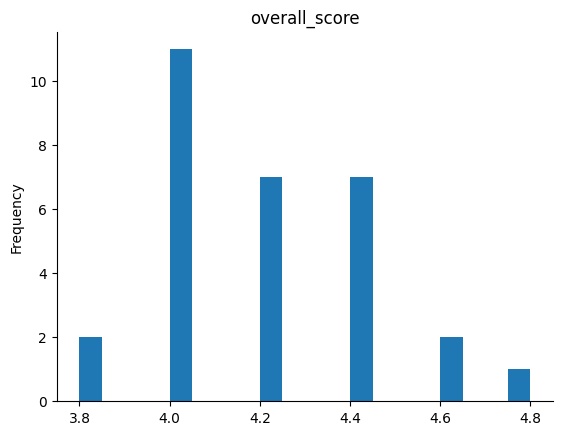

In [13]:
from matplotlib import pyplot as plt
results_df['overall_score'].plot(kind='hist', bins=20, title='overall_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

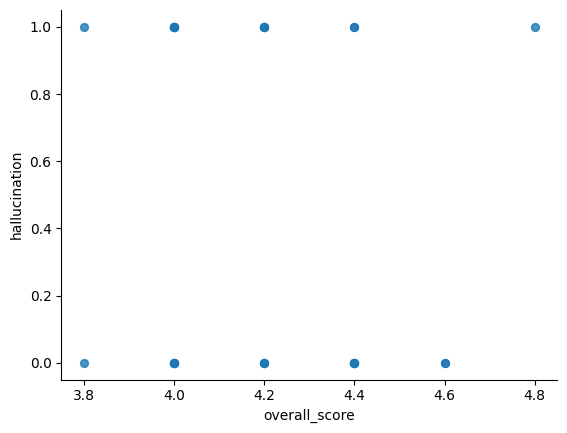

In [12]:
from matplotlib import pyplot as plt
results_df.plot(kind='scatter', x='overall_score', y='hallucination', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

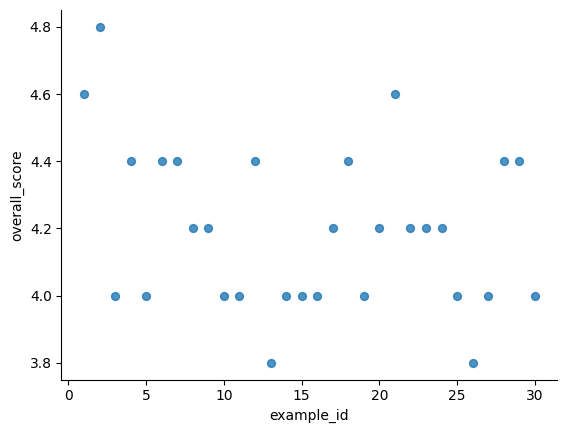

In [11]:
from matplotlib import pyplot as plt
results_df.plot(kind='scatter', x='example_id', y='overall_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

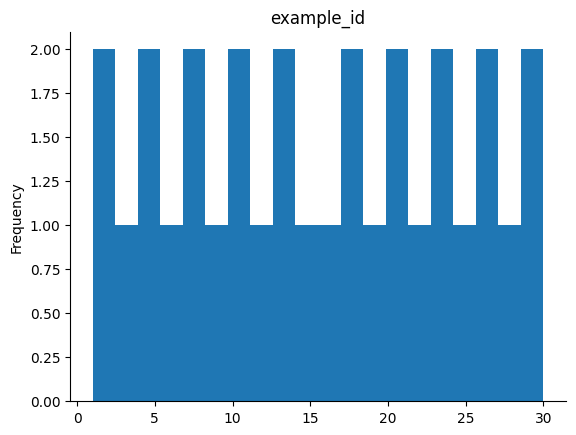

In [10]:
from matplotlib import pyplot as plt
results_df['example_id'].plot(kind='hist', bins=20, title='example_id')
plt.gca().spines[['top', 'right',]].set_visible(False)